In [1]:
# In diese Datei wird der Datensatz geladen und statischtisch analysiert. Diese Analyse hilft dabei, wichtige Merkmale zu identifizieren, die für das Training eines neuronalen Netzes relevant sein könnten.

In [2]:
# Notwendige Bibliotheken importieren
from sklearn.metrics import confusion_matrix
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
import math

In [3]:
# die Zielspalte "p" wird als target_column definiert, und die prepare_data-Funktion wird aufgerufen, um die Daten vorzubereiten und in Trainings- und Validierungsdaten aufzuteilen
target_column = "p"

structure_data = pd.read_csv("./training-daten.csv")

In [4]:
# StandardScaler verwenden, um die Daten zu normalisieren
# Klasse initialisieren
scaler = sk.preprocessing.StandardScaler()

# Klasse fitten, um die wichtige Information über 
# die Daten zu lernen (Mittelwert und Standardabweichung)
scaler.fit(structure_data)

# Daten transformieren
structure_data_normalised = scaler.transform(structure_data)

In [5]:
X_data = structure_data_normalised[:, 0:4]
Y_data = structure_data_normalised[:, 4]

In [6]:
from scipy.stats import pearsonr,spearmanr, kendalltau

# die Korrelation zwischen den Spalten und der Zielspalte "p" berechnen.
for col in structure_data.columns:
    if col != target_column:
        x = structure_data[col]
        y = structure_data[target_column]

        print(f"Analyse der Korrelation zwischen {col} und {target_column}:")
        r, p = pearsonr(x, y)
        print("Pearson-Korrelation:", r, "P-Wert:", p)
        rho, p = spearmanr(x, y)
        print("Spearman-Korrelation:", rho, "P-Wert:", p)
        tau, p = kendalltau(x, y)
        print("Kendall-Korrelation:", tau, "P-Wert:", p)

Analyse der Korrelation zwischen v und p:
Pearson-Korrelation: 0.8635308973975907 P-Wert: 0.0
Spearman-Korrelation: 0.8671127515577095 P-Wert: 0.0
Kendall-Korrelation: 0.7266635806621282 P-Wert: 0.0
Analyse der Korrelation zwischen d und p:
Pearson-Korrelation: -0.2877430194121125 P-Wert: 0.0
Spearman-Korrelation: -0.261390044835902 P-Wert: 0.0
Kendall-Korrelation: -0.1785885521574127 P-Wert: 0.0
Analyse der Korrelation zwischen s und p:
Pearson-Korrelation: -0.26453112121440514 P-Wert: 0.0
Spearman-Korrelation: -0.23034463902516736 P-Wert: 0.0
Kendall-Korrelation: -0.1553236003270546 P-Wert: 0.0
Analyse der Korrelation zwischen r und p:
Pearson-Korrelation: -0.005718908712411066 P-Wert: 0.14483358658505688
Spearman-Korrelation: -0.0019415696652897373 P-Wert: 0.6206029245669188
Kendall-Korrelation: -0.0015866191501261522 P-Wert: 0.620599222081123


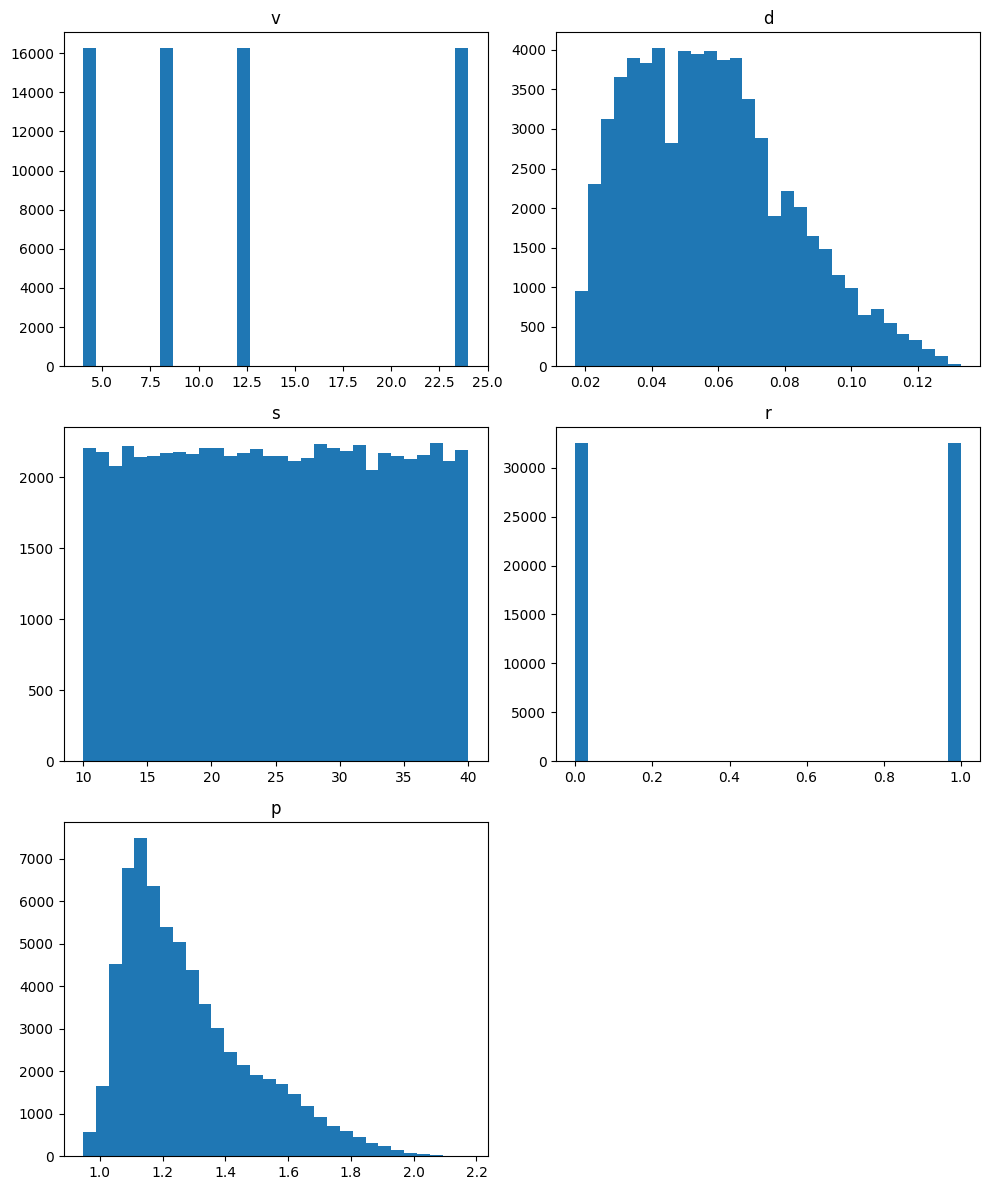

In [7]:
# die Normalverteilung der Spalten visualisieren
def plot_normal_distributions(df, cols, ncols=3):
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        data = df[col].dropna()
        mu, std = data.mean(), data.std()

        x = np.linspace(data.min(), data.max(), 200)
        y = norm.pdf(x, mu, std)

        axes[i].hist(data, bins=30, density=False)
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_normal_distributions(structure_data, structure_data.columns, 2)

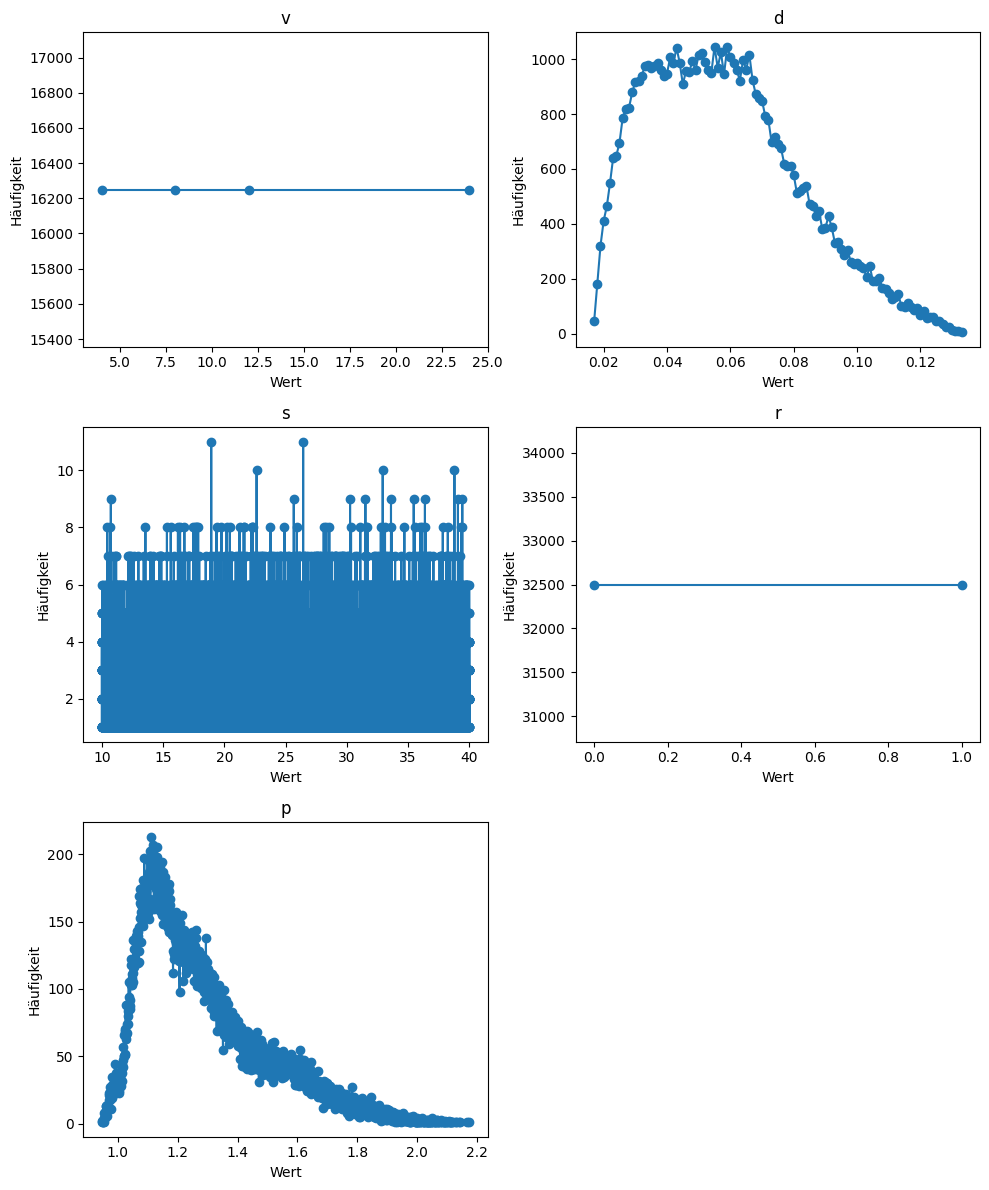

In [8]:
# die Häufigkeit der Werte visualisieren
def plot_frequency_lines(df, cols, ncols=3):
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        freq = df[col].value_counts().sort_index()
        axes[i].plot(freq.index, freq.values, marker="o")
        axes[i].set_title(col)
        axes[i].set_xlabel("Wert")
        axes[i].set_ylabel("Häufigkeit")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_frequency_lines(structure_data, structure_data.columns, 2)

In [9]:
structure_data[target_column].value_counts()

p
1.110    213
1.118    207
1.129    205
1.112    202
1.107    202
        ... 
2.115      1
2.143      1
0.949      1
2.070      1
2.107      1
Name: count, Length: 1133, dtype: int64

In [10]:
# eine zufällige Stichprobe der Daten erstellen
structure_data_shuffled = structure_data.sample(n=len(structure_data), random_state=1)
print(structure_data_shuffled)

        v      d       s  r      p
15099  24  0.052  26.589  0  1.427
51459  24  0.043  13.075  0  1.553
33751  24  0.045  24.611  1  1.603
23098  12  0.080  24.349  0  1.117
37351  24  0.031  14.012  1  1.829
...    ..    ...     ... ..    ...
32511  24  0.063  22.672  1  1.451
5192    4  0.070  29.276  0  1.027
12172   4  0.046  15.812  1  1.125
33003  24  0.100  34.524  0  1.346
62501   8  0.041  23.697  1  1.115

[65000 rows x 5 columns]


In [11]:
# Die ersten 2 Zeilen jeder Spalte vor und nach der Normalisierung anzeigen
rows_to_show = 2
col_names = structure_data.columns
col_count = structure_data.shape[1] - 1

for i in range(col_count):
    col_name = col_names[i]
    print(f"Spalte: {col_name}")
    for row in range(rows_to_show):
        print(f"Wert: {structure_data[col_name][row]}, Norm. Wert: {X_data[row, i]}") 


Spalte: v
Wert: 4, Norm. Wert: -1.0690449676496976
Wert: 8, Norm. Wert: -0.5345224838248488
Spalte: d
Wert: 0.052, Norm. Wert: -0.24398501964801353
Wert: 0.047, Norm. Wert: -0.45647394940875297
Spalte: s
Wert: 19.155, Norm. Wert: -0.6744551610927914
Wert: 24.478, Norm. Wert: -0.05971118512126529
Spalte: r
Wert: 0, Norm. Wert: -1.0
Wert: 0, Norm. Wert: -1.0


In [12]:
# Häufigkeitstabelle
def freq_table_and_dict(col_name, col):
    values, counts = np.unique(col, return_counts=True)

    freq_table = np.column_stack((values, counts))
    freq_dict = dict(zip(values, counts))
    # Sort freq_dict by count (values) descending
    sorted_freq = dict(sorted(freq_dict.items(), key=lambda item: item[1], reverse=True))

    return freq_table, freq_dict

for col in structure_data.columns:
    freq_table_1, freq_dict_1 = freq_table_and_dict(col, structure_data[col])
    # print(f"Frequency table for {col}:\n{freq_dict_1}\n")

In [13]:
# Statistische Kennzahlen für eine Spalte berechnen
def get_col_stats(col_name, col):
    values, counts = np.unique(col, return_counts=True)
    return {
        "mittelwert": np.mean(col),
        "median": np.median(col),
        "modalwert": values[np.argmax(counts)],
        "seltenster_wert": values[np.argmin(counts)],
        "standardabweichung": np.std(col),
        "min": np.min(col),
        "max": np.max(col),
    }

for col in structure_data.columns:
    print(f"Analyse der Spalte: {col}")
    col_stats = get_col_stats(col, structure_data[col])
    print(f"Mittelwert: {col_stats['mittelwert']}, Median: {col_stats['median']}, Modalwert: {col_stats['modalwert']}, \nSeltenster Wert: {col_stats['seltenster_wert']}, Standardabweichung: {col_stats['standardabweichung']}, Min: {col_stats['min']}, Max: {col_stats['max']}\n")

Analyse der Spalte: v
Mittelwert: 12.0, Median: 10.0, Modalwert: 4, 
Seltenster Wert: 4, Standardabweichung: 7.483314773547883, Min: 4, Max: 24

Analyse der Spalte: d
Mittelwert: 0.05774112307692307, Median: 0.055, Modalwert: 0.055, 
Seltenster Wert: 0.133, Standardabweichung: 0.023530637599003163, Min: 0.017, Max: 0.133

Analyse der Spalte: s
Mittelwert: 24.995032538461537, Median: 24.98, Modalwert: 18.935, 
Seltenster Wert: 10.008, Standardabweichung: 8.658889241798041, Min: 10.0, Max: 40.0

Analyse der Spalte: r
Mittelwert: 0.5, Median: 0.5, Modalwert: 0, 
Seltenster Wert: 0, Standardabweichung: 0.5, Min: 0, Max: 1

Analyse der Spalte: p
Mittelwert: 1.282704630769231, Median: 1.231, Modalwert: 1.11, 
Seltenster Wert: 0.946, Standardabweichung: 0.20696525231233823, Min: 0.946, Max: 2.174



In [14]:
# die k häufigsten und k seltensten Werte inkl. ihrer
# Häufigkeit in einer Liste arr zurückgeben
def top_and_least_k_frequent(arr, k=5):
    values, counts = np.unique(arr, return_counts=True)
    
    # Absteigend sortieren für die häufigsten Werte
    top_indices = np.argsort(-counts)[:k]
    top_k = np.column_stack((values[top_indices], counts[top_indices]))
    
    # Aufsteigend sortieren für die seltensten Werte
    least_indices = np.argsort(counts)[:k]
    least_k = np.column_stack((values[least_indices], counts[least_indices]))
    
    return top_k, least_k

for col in structure_data.columns:
    top, least = top_and_least_k_frequent(structure_data[col], k=5)
    print(f"Top 5 häufigste Werte für {col}:\n{top}\n")
    print(f"Top 5 seltenste Werte für {col}:\n{least}\n")


Top 5 häufigste Werte für v:
[[    4 16250]
 [    8 16250]
 [   12 16250]
 [   24 16250]]

Top 5 seltenste Werte für v:
[[    4 16250]
 [    8 16250]
 [   12 16250]
 [   24 16250]]

Top 5 häufigste Werte für d:
[[5.500e-02 1.046e+03]
 [5.900e-02 1.043e+03]
 [4.300e-02 1.041e+03]
 [5.700e-02 1.026e+03]
 [5.100e-02 1.022e+03]]

Top 5 seltenste Werte für d:
[[ 0.133  4.   ]
 [ 0.131  9.   ]
 [ 0.132 10.   ]
 [ 0.13  12.   ]
 [ 0.129 23.   ]]

Top 5 häufigste Werte für s:
[[18.935 11.   ]
 [26.441 11.   ]
 [32.935 10.   ]
 [38.789 10.   ]
 [22.64  10.   ]]

Top 5 seltenste Werte für s:
[[10.01   1.   ]
 [10.008  1.   ]
 [18.451  1.   ]
 [18.448  1.   ]
 [18.447  1.   ]]

Top 5 häufigste Werte für r:
[[    0 32500]
 [    1 32500]]

Top 5 seltenste Werte für r:
[[    0 32500]
 [    1 32500]]

Top 5 häufigste Werte für p:
[[  1.11  213.   ]
 [  1.118 207.   ]
 [  1.129 205.   ]
 [  1.107 202.   ]
 [  1.112 202.   ]]

Top 5 seltenste Werte für p:
[[0.946 1.   ]
 [0.949 1.   ]
 [2.069 1.   ]
 [